In [1]:
from utils.gandataset import GANDataset
from utils.transforms import RescaledRotationTransform, GANTransform, GANTransformRotate
from utils.config import PROJECT_ROOT
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
transform = RescaledRotationTransform()
# filepath= Path(PROJECT_ROOT) / "data/WaterOnlyDailySmall/WaterOnlyDailyExtendedSeasonalitySmall.nc"
filepath = Path(PROJECT_ROOT) / "data/WaterOnlyMonthlySmall/WaterOnlyMonthlyExtendedSeasonalitySmall.nc"
season = f"all"  

dataset = GANDataset(filepath=filepath, transform=transform, normalize=True, season=season, lat_lon=False)

/mnt/c/Users/samue/SynologyDrive/OceanPropInfSatImg/src/utils/datasettemporal.py:69: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, _ in self.dataset.dims.items():
<frozen _collections_abc>:894: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


In [3]:
dataset.dataset

<xarray.Dataset> Size: 71MB
Dimensions:    (depth: 1, latitude: 61, longitude: 61, time: 342)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 244B 45.0 45.08 45.17 ... 49.83 49.92 50.0
  * longitude  (longitude) float32 244B -153.0 -152.9 -152.8 ... -148.1 -148.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2021-06-01
Data variables:
    bottomT    (time, latitude, longitude) float64 10MB ...
    so         (time, depth, latitude, longitude) float64 10MB ...
    thetao     (time, depth, latitude, longitude) float64 10MB ...
    uo         (time, depth, latitude, longitude) float64 10MB ...
    vo         (time, depth, latitude, longitude) float64 10MB ...
    zos        (time, latitude, longitude) float64 10MB ...
    mlotst     (time, latitude, longitude) float64 10MB ...
Attributes:
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    credit:                    E.U. Copernicus Marine Service Information (CM...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               Mercator Ocean
    title:                     Monthly mean fields for product GLOBAL_REANALY...
    source:                    MERCATOR GLORYS12V1
    references:                http://marine.copernicus.eu
    Conventions:               CF-1.6
    copernicusmarine_version:  2.1.0

Input shape: torch.Size([6, 61, 61]), Label shape: torch.Size([1, 61, 61])


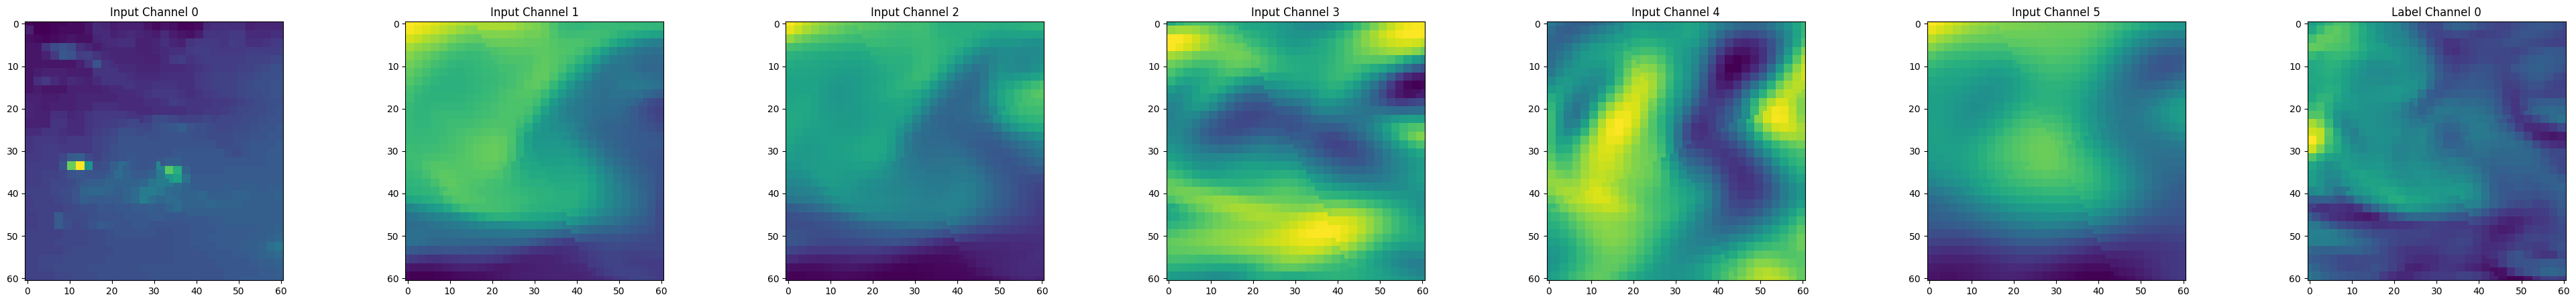

In [27]:
X, y = dataset[2]
print(f"Input shape: {X.shape}, Label shape: {y.shape}")
fig, ax = plt.subplots(1, X.shape[0]+1, figsize=(50, 5))
for i in range(X.shape[0]):
    ax[i].imshow(X[i, :, :], cmap="viridis")
    ax[i].set_title(f"Input Channel {i}")
ax[X.shape[0]].imshow(y[0], cmap="viridis")
ax[X.shape[0]].set_title(f"Label Channel {0}")
plt.show()


Input shape: torch.Size([6, 61, 61]), Label shape: torch.Size([1, 61, 61])


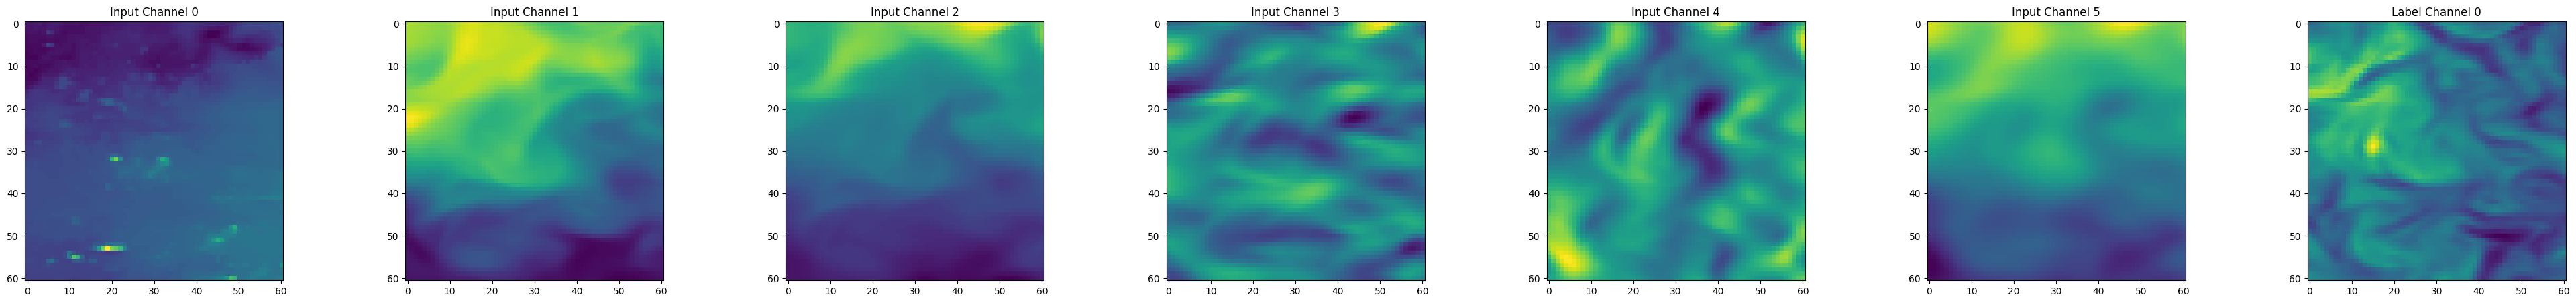

In [5]:
transform = dataset.transform
dataset.transform = None
X, y = dataset[2]
print(f"Input shape: {X.shape}, Label shape: {y.shape}")
fig, ax = plt.subplots(1, X.shape[0]+1, figsize=(50, 5))
for i in range(X.shape[0]):
    ax[i].imshow(X[i, :, :], cmap="viridis")
    ax[i].set_title(f"Input Channel {i}")
ax[X.shape[0]].imshow(y[0], cmap="viridis")
ax[X.shape[0]].set_title(f"Label Channel {0}")
plt.show()
dataset.transform = transform